In [66]:
import matplotlib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
%matplotlib inline

In [130]:

data = pd.read_csv('/content/Final_data (1).csv')
data.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,...,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc,Burns_Calories_Bin
0,34.91,Male,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,Strength,...,2139.59,0.500432,1.624789,0.741237,0.835985,725.10,47.777394,685.1600,7.260425e+19,Medium
1,23.37,Female,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,HIIT,...,1711.65,0.500850,1.514093,0.551247,0.734270,-232.91,40.809803,978.6184,1.020506e+20,High
2,33.20,Female,58.98,1.67,175.04,123.95,54.96,0.91,802.26,Cardio,...,1965.92,0.500610,1.663445,0.574534,0.708124,805.74,44.635580,654.5266,1.079607e+20,High
3,38.69,Female,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,HIIT,...,1627.28,0.499533,0.862017,0.744155,0.811150,1206.21,63.007432,773.6300,8.987921e+19,High
4,45.09,Male,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,Strength,...,2659.23,0.500581,2.538153,0.668405,0.789751,303.60,43.347504,711.4176,5.264685e+19,Low


In [68]:
data.dtypes

,0
Age,float64
Gender,object
Weight (kg),float64
Height (m),float64
Max_BPM,float64
Avg_BPM,float64
Resting_BPM,float64
Session_Duration (hours),float64
Calories_Burned,float64
Workout_Type,object


Text(0.5, 1.0, 'Age Distribution')

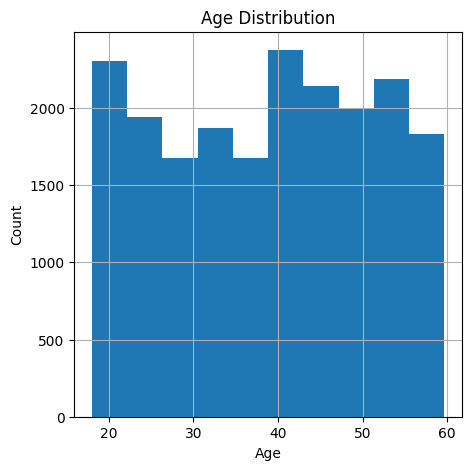

In [69]:
data['Age'].hist(figsize=(5, 5))
plt.xlabel('Age')
plt.ylabel('Count')
plt.title("Age Distribution")

Text(0.5, 1.0, 'Gender Distribution')

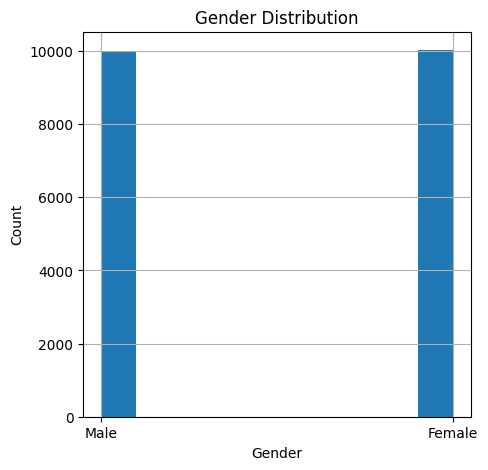

In [70]:
data['Gender'].hist(figsize=(5, 5))
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title("Gender Distribution")


Text(0.5, 1.0, 'Weight Distribution')

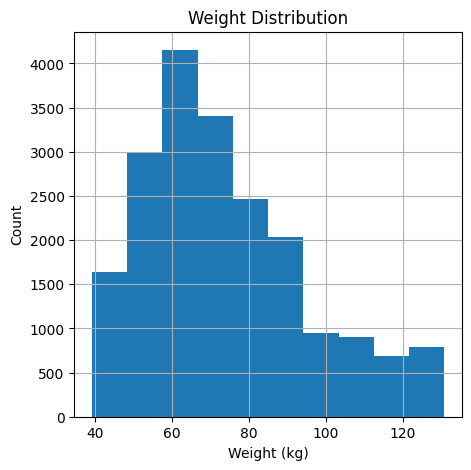

In [71]:
data["Weight (kg)"].hist(figsize=(5, 5))
plt.xlabel('Weight (kg)')
plt.ylabel('Count')
plt.title("Weight Distribution")

Text(0.5, 1.0, 'Height Distribution')

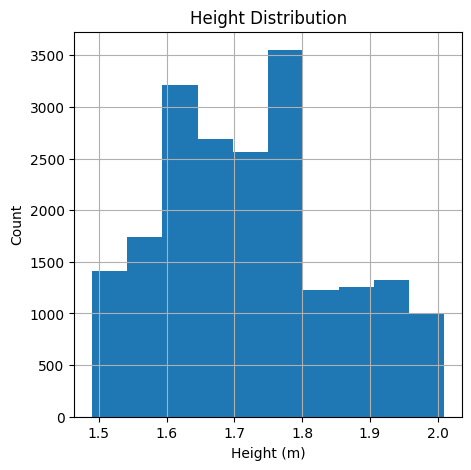

In [72]:
data["Height (m)"].hist(figsize=(5, 5))
plt.xlabel('Height (m)')
plt.ylabel('Count')
plt.title("Height Distribution")

Text(0.5, 1.0, 'Weight V. Height')

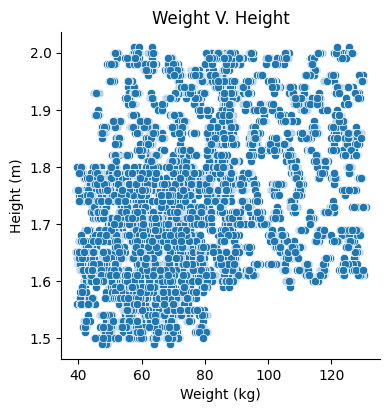

In [73]:
sns.relplot(x = "Weight (kg)", y = "Height (m)", data = data, height=4, aspect=1)
plt.xlabel('Weight (kg)')
plt.ylabel('Height (m)')
plt.title("Weight V. Height")


Text(0.5, 1.0, 'Session Duration V. Calories Burned')

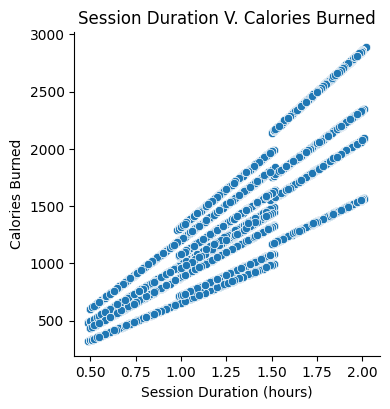

In [74]:
sns.relplot(x = "Session_Duration (hours)", y = "Calories_Burned", data = data,height=4, aspect=1)
plt.xlabel('Session Duration (hours)')
plt.ylabel('Calories Burned')
plt.title("Session Duration V. Calories Burned")


In [75]:
data.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,...,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc,Burns_Calories_Bin
0,34.91,Male,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,Strength,...,2139.59,0.500432,1.624789,0.741237,0.835985,725.10,47.777394,685.1600,7.260425e+19,Medium
1,23.37,Female,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,HIIT,...,1711.65,0.500850,1.514093,0.551247,0.734270,-232.91,40.809803,978.6184,1.020506e+20,High
2,33.20,Female,58.98,1.67,175.04,123.95,54.96,0.91,802.26,Cardio,...,1965.92,0.500610,1.663445,0.574534,0.708124,805.74,44.635580,654.5266,1.079607e+20,High
3,38.69,Female,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,HIIT,...,1627.28,0.499533,0.862017,0.744155,0.811150,1206.21,63.007432,773.6300,8.987921e+19,High
4,45.09,Male,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,Strength,...,2659.23,0.500581,2.538153,0.668405,0.789751,303.60,43.347504,711.4176,5.264685e+19,Low


In [76]:
x = data[["Age", "Weight (kg)", "Height (m)", "Session_Duration (hours)", "Avg_BPM", "Resting_BPM", "Max_BPM"]]
x

,Age,Weight (kg),Height (m),Session_Duration (hours),Avg_BPM,Resting_BPM,Max_BPM
0,34.91,65.27,1.62,1.00,157.65,69.05,188.58
1,23.37,56.41,1.55,1.37,131.75,73.18,179.43
2,33.20,58.98,1.67,0.91,123.95,54.96,175.04
3,38.69,93.78,1.70,1.10,155.10,50.07,191.21
4,45.09,52.42,1.88,1.08,152.88,70.84,193.58
...,...,...,...,...,...,...,...
19995,46.77,98.31,1.90,0.77,148.18,63.72,199.20
19996,40.38,88.12,1.87,1.97,134.18,54.04,196.18
19997,50.31,46.20,1.67,1.36,157.92,61.65,163.34
19998,52.36,44.30,1.62,1.41,121.23,60.88,179.27


In [77]:
y = data["Calories_Burned"]
y

,Calories_Burned
0,1080.90
1,1809.91
2,802.26
3,1450.79
4,1166.40
...,...
19995,761.61
19996,2303.13
19997,1468.80
19998,929.75


In [78]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.20,random_state = 40)

In [79]:
dt = DecisionTreeRegressor(max_depth = 5)
dt.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=5)

In [80]:
dt_pred = dt.predict(x_test)
dt_pred

array([1081.00413259, 2151.79915374, 1081.00413259, ..., 1420.91861272,
       1276.03213725, 1081.00413259])

In [81]:
mse = mean_squared_error(y_test, dt_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 84196.73113798654


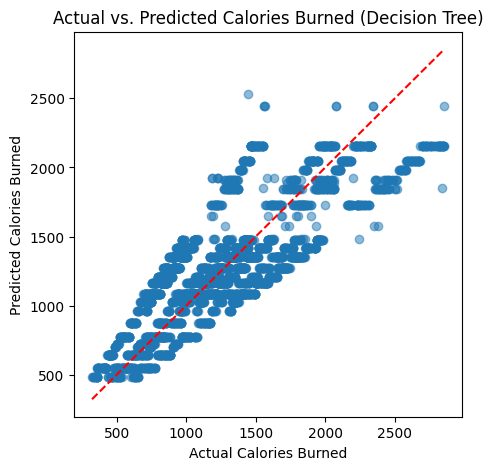

In [82]:
plt.figure(figsize=(5, 5))
plt.scatter(y_test, dt_pred, alpha=0.5)
plt.xlabel('Actual Calories Burned')
plt.ylabel('Predicted Calories Burned')
plt.title('Actual vs. Predicted Calories Burned (Decision Tree)')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

DecisionTreeRegressor(max_depth=8)

array([1010.23626984, 2148.57726087, 1010.23626984, ..., 1344.77614286,
       1348.15206897, 1132.86571429])

Mean Squared Error: 87853.44136862484


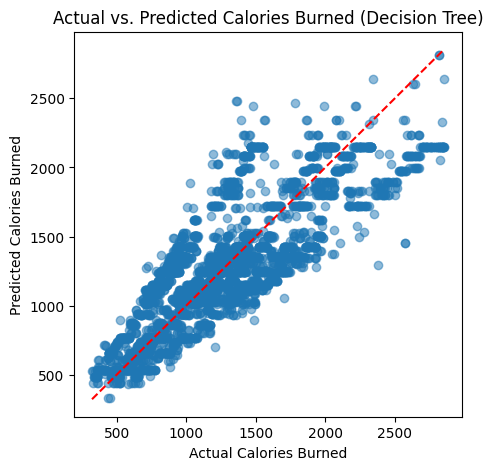

In [83]:
dt2 = DecisionTreeRegressor(max_depth = 8)
display(dt2.fit(x_train, y_train))
dt2_pred = dt2.predict(x_test)
display(dt2_pred)
mse = mean_squared_error(y_test, dt2_pred)
print("Mean Squared Error:", mse)
plt.figure(figsize=(5, 5))
plt.scatter(y_test, dt2_pred, alpha=0.5)
plt.xlabel('Actual Calories Burned')
plt.ylabel('Predicted Calories Burned')
plt.title('Actual vs. Predicted Calories Burned (Decision Tree)')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

DecisionTreeRegressor(max_depth=12)

array([1182.64142857, 2737.1375    , 1020.80283582, ..., 1324.81852941,
       1289.1835    ,  698.96      ])

Mean Squared Error: 99206.30566093985


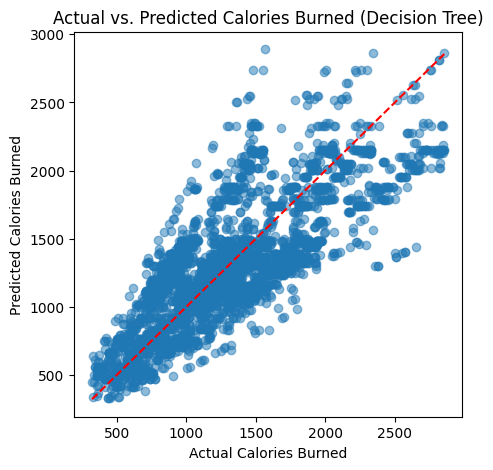

In [84]:
dt3 = DecisionTreeRegressor(max_depth = 12)
display(dt3.fit(x_train, y_train))
dt3_pred = dt3.predict(x_test)
display(dt3_pred)
mse = mean_squared_error(y_test, dt3_pred)
print("Mean Squared Error:", mse)
plt.figure(figsize=(5, 5))
plt.scatter(y_test, dt3_pred, alpha=0.5)
plt.xlabel('Actual Calories Burned')
plt.ylabel('Predicted Calories Burned')
plt.title('Actual vs. Predicted Calories Burned (Decision Tree)')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

RandomForestRegressor(max_depth=5, n_estimators=500)

82957.4735715282

Mean Squared Error: 82957.4735715282


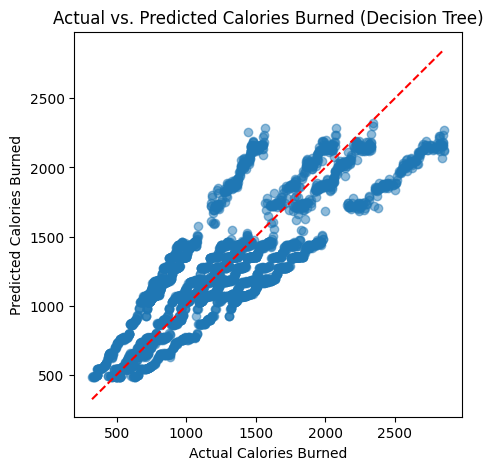

In [85]:
rf= RandomForestRegressor(n_estimators = 500, max_depth = 5)
display(rf.fit(x_train, y_train))

rf_pred = rf.predict(x_test)

mse = mean_squared_error(y_test, rf_pred)
display(mse)
print("Mean Squared Error:", mse)
plt.figure(figsize=(5, 5))
plt.scatter(y_test, rf_pred, alpha=0.5)
plt.xlabel('Actual Calories Burned')
plt.ylabel('Predicted Calories Burned')
plt.title('Actual vs. Predicted Calories Burned (Decision Tree)')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

RandomForestRegressor(max_depth=8, n_estimators=800)

83604.28467531221

Mean Squared Error: 83604.28467531221


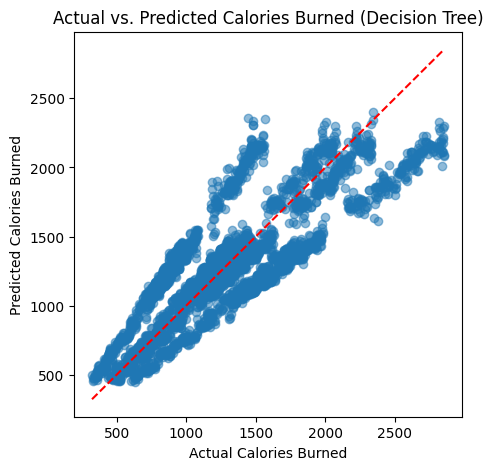

In [86]:
rf2= RandomForestRegressor(n_estimators = 800, max_depth = 8)
display(rf2.fit(x_train, y_train))

rf2_pred = rf2.predict(x_test)

mse = mean_squared_error(y_test, rf2_pred)
display(mse)
print("Mean Squared Error:", mse)
plt.figure(figsize=(5, 5))
plt.scatter(y_test, rf2_pred, alpha=0.5)
plt.xlabel('Actual Calories Burned')
plt.ylabel('Predicted Calories Burned')
plt.title('Actual vs. Predicted Calories Burned (Decision Tree)')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

RandomForestRegressor(max_depth=5, n_estimators=1000)

82938.28163094813

Mean Squared Error: 82938.28163094813


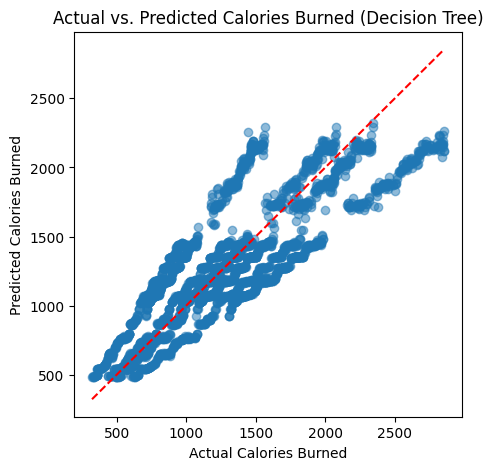

In [87]:
rf3= RandomForestRegressor(n_estimators = 1000, max_depth = 5)
display(rf3.fit(x_train, y_train))

rf3_pred = rf3.predict(x_test)

mse = mean_squared_error(y_test, rf3_pred)
display(mse)
print("Mean Squared Error:", mse)
plt.figure(figsize=(5, 5))
plt.scatter(y_test, rf3_pred, alpha=0.5)
plt.xlabel('Actual Calories Burned')
plt.ylabel('Predicted Calories Burned')
plt.title('Actual vs. Predicted Calories Burned (Decision Tree)')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()


In [131]:
data.head()


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,...,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc,Burns_Calories_Bin
0,34.91,Male,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,Strength,...,2139.59,0.500432,1.624789,0.741237,0.835985,725.10,47.777394,685.1600,7.260425e+19,Medium
1,23.37,Female,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,HIIT,...,1711.65,0.500850,1.514093,0.551247,0.734270,-232.91,40.809803,978.6184,1.020506e+20,High
2,33.20,Female,58.98,1.67,175.04,123.95,54.96,0.91,802.26,Cardio,...,1965.92,0.500610,1.663445,0.574534,0.708124,805.74,44.635580,654.5266,1.079607e+20,High
3,38.69,Female,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,HIIT,...,1627.28,0.499533,0.862017,0.744155,0.811150,1206.21,63.007432,773.6300,8.987921e+19,High
4,45.09,Male,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,Strength,...,2659.23,0.500581,2.538153,0.668405,0.789751,303.60,43.347504,711.4176,5.264685e+19,Low


In [132]:
new_data = data[["Age","Weight (kg)", "Height (m)", "Max_BPM", "Avg_BPM","Resting_BPM", "Session_Duration (hours)", "Calories_Burned"]]
new_data.head()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned
0,34.91,65.27,1.62,188.58,157.65,69.05,1.00,1080.90
1,23.37,56.41,1.55,179.43,131.75,73.18,1.37,1809.91
2,33.20,58.98,1.67,175.04,123.95,54.96,0.91,802.26
3,38.69,93.78,1.70,191.21,155.10,50.07,1.10,1450.79
4,45.09,52.42,1.88,193.58,152.88,70.84,1.08,1166.40


In [133]:
encoder = OneHotEncoder(handle_unknown = "ignore", sparse_output = False)
gender_encoded = encoder.fit_transform(data[["Gender"]])
print(gender_encoded)
print(encoder.get_feature_names_out(['Gender']))

[[0. 1.]
 [1. 0.]
 [1. 0.]
 ...
 [0. 1.]
 [0. 1.]
 [0. 1.]]
['Gender_Female' 'Gender_Male']


In [134]:
gender_df = pd.DataFrame(gender_encoded, columns = encoder.get_feature_names_out(['Gender']))
data_encoded = pd.concat([new_data, gender_df], axis = 1)
data_encoded.head()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Gender_Female,Gender_Male
0,34.91,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,0.0,1.0
1,23.37,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,1.0,0.0
2,33.20,58.98,1.67,175.04,123.95,54.96,0.91,802.26,1.0,0.0
3,38.69,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,1.0,0.0
4,45.09,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,0.0,1.0


In [135]:
standardizer = StandardScaler()


In [136]:
data_standardized = standardizer.fit_transform(data_encoded)
data_standardized_df = pd.DataFrame(data_standardized, columns = data_encoded.columns)

data_standardized_df

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Gender_Female,Gender_Male
0,-0.325356,-0.407549,-0.811571,0.754988,0.977456,0.940325,-0.760110,-0.396661,-1.002804,1.002804
1,-1.277951,-0.826017,-1.362623,-0.039938,-0.837880,1.506919,0.323893,1.054924,0.997204,-0.997204
2,-0.466512,-0.704633,-0.417962,-0.421328,-1.384583,-0.992680,-1.023786,-0.951481,0.997204,-0.997204
3,-0.013328,0.939010,-0.181796,0.983474,0.798726,-1.663539,-0.467136,0.339854,0.997204,-0.997204
4,0.514975,-1.014469,1.235196,1.189373,0.643126,1.185895,-0.525731,-0.226416,-1.002804,1.002804
...,...,...,...,...,...,...,...,...,...,...
19995,0.653654,1.152967,1.392640,1.677622,0.313702,0.209103,-1.433949,-1.032423,0.997204,-0.997204
19996,0.126177,0.671682,1.156474,1.415253,-0.667560,-1.118895,2.081734,2.037011,0.997204,-0.997204
19997,0.945871,-1.308247,-0.417962,-1.437790,0.996381,-0.074880,0.294595,0.375715,-1.002804,1.002804
19998,1.115093,-1.397986,-0.811571,-0.053838,-1.575228,-0.180516,0.441082,-0.697627,-1.002804,1.002804


In [137]:
inertias = []
for k in range(1,11):
  km = KMeans(n_clusters = k)
  km.fit(data_standardized_df)
  clusters = km.predict(data_standardized_df)
  inertias.append(km.inertia_)
inertias

[200000.0000000006,
 159996.3473607164,
 148960.67647747335,
 138365.53789082804,
 129528.59484278777,
 125153.20147819756,
 117725.09718393818,
 113348.16665528053,
 110494.42729430097,
 107648.07366338727]

Text(0, 0.5, 'Inertias')

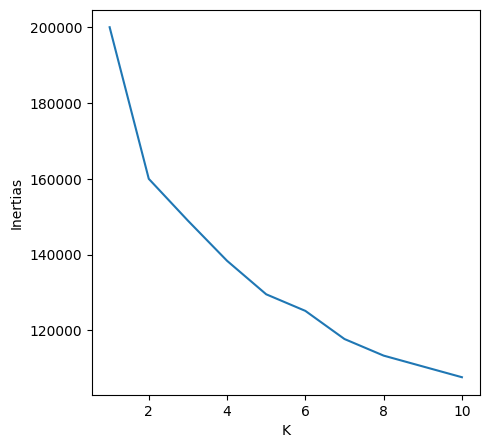

In [138]:
plt.figure(figsize=(5, 5))
plt.plot(range(1,11), inertias)
plt.xlabel("K")
plt.ylabel("Inertias")

In [139]:
silhouette_list = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(data_standardized)
    clusters = kmeans.predict(data_standardized)
    score = silhouette_score(data_standardized,clusters)
    silhouette_list.append(score)
silhouette_list

[np.float64(0.20065067437371042),
 np.float64(0.14764092906718757),
 np.float64(0.15933916809095103),
 np.float64(0.1276574840231218),
 np.float64(0.13568100975835554),
 np.float64(0.12744834514633596),
 np.float64(0.1206784896701168),
 np.float64(0.12103186686189434),
 np.float64(0.11866039264080173)]

Text(0, 0.5, 'Silhouette Score')

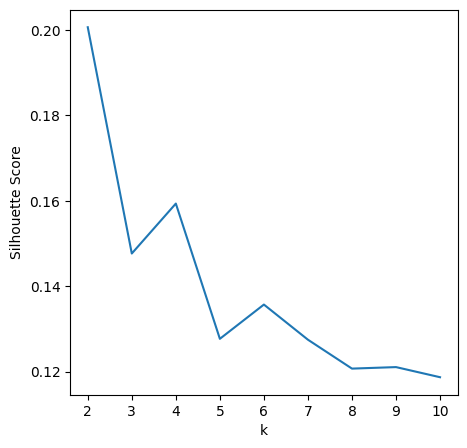

In [140]:
plt.figure(figsize=(5, 5))
plt.plot(range(2,11), silhouette_list)
plt.xlabel("k")
plt.ylabel("Silhouette Score")

In [141]:
km2 = KMeans(n_clusters = 2)
km2.fit(data_standardized)
clusters = km2.predict(data_standardized)
clusters

array([1, 0, 0, ..., 1, 1, 1], dtype=int32)

In [143]:
data['clusters'] = clusters
data

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,...,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc,Burns_Calories_Bin,clusters
0,34.91,Male,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,Strength,...,0.500432,1.624789,0.741237,0.835985,725.10,47.777394,685.1600,7.260425e+19,Medium,1
1,23.37,Female,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,HIIT,...,0.500850,1.514093,0.551247,0.734270,-232.91,40.809803,978.6184,1.020506e+20,High,0
2,33.20,Female,58.98,1.67,175.04,123.95,54.96,0.91,802.26,Cardio,...,0.500610,1.663445,0.574534,0.708124,805.74,44.635580,654.5266,1.079607e+20,High,0
3,38.69,Female,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,HIIT,...,0.499533,0.862017,0.744155,0.811150,1206.21,63.007432,773.6300,8.987921e+19,High,0
4,45.09,Male,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,Strength,...,0.500581,2.538153,0.668405,0.789751,303.60,43.347504,711.4176,5.264685e+19,Low,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,46.77,Female,98.31,1.90,199.20,148.18,63.72,0.77,761.61,Strength,...,0.500000,0.954837,0.623413,0.743876,1865.39,71.269345,533.2558,7.924402e+19,Medium,0
19996,40.38,Female,88.12,1.87,196.18,134.18,54.04,1.97,2303.13,Strength,...,0.496968,0.689060,0.563810,0.683964,173.87,65.049689,1310.6016,5.708474e+19,Low,0
19997,50.31,Male,46.20,1.67,163.34,157.92,61.65,1.36,1468.80,Strength,...,0.500280,2.105844,0.946701,0.966818,-43.80,35.420708,957.9568,9.101285e+19,High,1
19998,52.36,Male,44.30,1.62,179.27,121.23,60.88,1.41,929.75,Yoga,...,0.499940,2.190745,0.509756,0.676243,346.25,35.889260,928.4004,5.246436e+19,Low,1


Text(0.5, 1.0, 'Max_BPM vs. Calories Burned')

<Figure size 500x500 with 0 Axes>

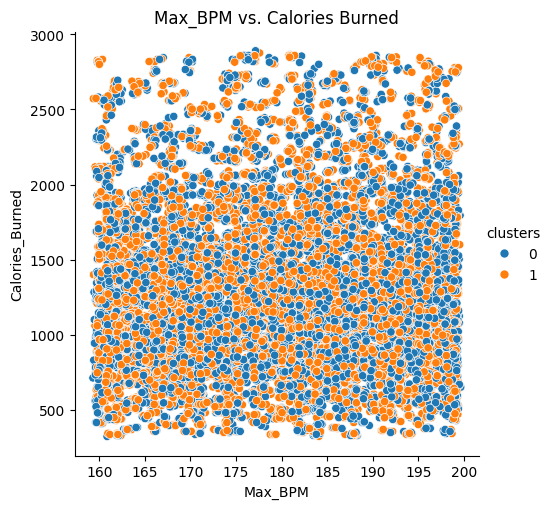

In [144]:
plt.figure(figsize=(5, 5))
sns.relplot(x = "Max_BPM", y = "Calories_Burned", data = data, hue = "clusters" )
plt.title("Max_BPM vs. Calories Burned")

Text(0.5, 1.0, 'Clusters based on Session Duration vs. Calories Burned')

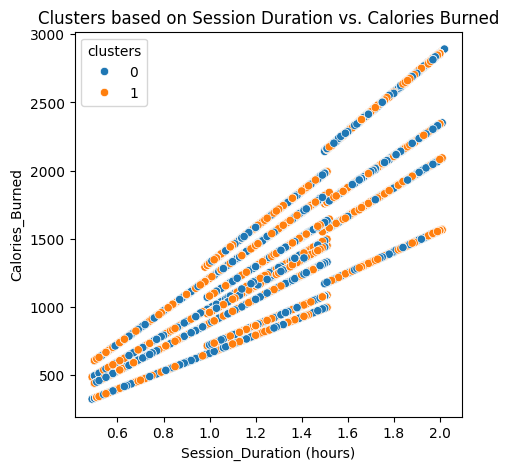

In [145]:
plt.figure(figsize=(5, 5))
sns.scatterplot(x='Session_Duration (hours)', y='Calories_Burned', hue='clusters', data=data)
plt.title('Clusters based on Session Duration vs. Calories Burned')

Text(0.5, 1.0, 'Clusters based on Average BPM vs. Calories Burned')

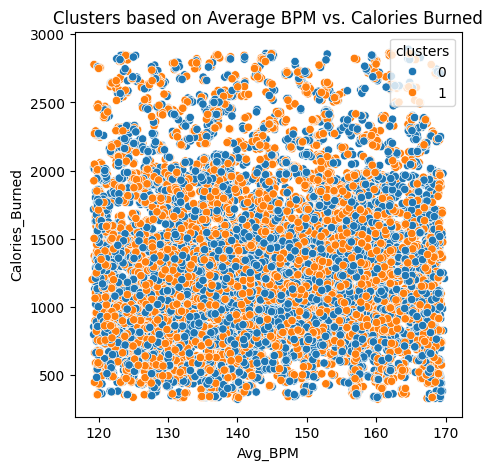

In [146]:
plt.figure(figsize=(5, 5))
sns.scatterplot(x='Avg_BPM', y='Calories_Burned', hue='clusters', data=data)
plt.title('Clusters based on Average BPM vs. Calories Burned')

In [103]:
km3 = KMeans(n_clusters = 4)
km3.fit(data_standardized)
clusters = km3.predict(data_standardized)
clusters


array([0, 2, 2, ..., 0, 0, 0], dtype=int32)

In [104]:
data['clusters'] = clusters
data

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,...,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc,Burns_Calories_Bin,clusters
0,34.91,Male,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,Strength,...,0.500432,1.624789,0.741237,0.835985,725.10,47.777394,685.1600,7.260425e+19,Medium,0
1,23.37,Female,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,HIIT,...,0.500850,1.514093,0.551247,0.734270,-232.91,40.809803,978.6184,1.020506e+20,High,2
2,33.20,Female,58.98,1.67,175.04,123.95,54.96,0.91,802.26,Cardio,...,0.500610,1.663445,0.574534,0.708124,805.74,44.635580,654.5266,1.079607e+20,High,2
3,38.69,Female,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,HIIT,...,0.499533,0.862017,0.744155,0.811150,1206.21,63.007432,773.6300,8.987921e+19,High,3
4,45.09,Male,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,Strength,...,0.500581,2.538153,0.668405,0.789751,303.60,43.347504,711.4176,5.264685e+19,Low,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,46.77,Female,98.31,1.90,199.20,148.18,63.72,0.77,761.61,Strength,...,0.500000,0.954837,0.623413,0.743876,1865.39,71.269345,533.2558,7.924402e+19,Medium,3
19996,40.38,Female,88.12,1.87,196.18,134.18,54.04,1.97,2303.13,Strength,...,0.496968,0.689060,0.563810,0.683964,173.87,65.049689,1310.6016,5.708474e+19,Low,1
19997,50.31,Male,46.20,1.67,163.34,157.92,61.65,1.36,1468.80,Strength,...,0.500280,2.105844,0.946701,0.966818,-43.80,35.420708,957.9568,9.101285e+19,High,0
19998,52.36,Male,44.30,1.62,179.27,121.23,60.88,1.41,929.75,Yoga,...,0.499940,2.190745,0.509756,0.676243,346.25,35.889260,928.4004,5.246436e+19,Low,0


Text(0.5, 1.0, 'Clusters based on Max_BPM vs. Calories Burned')

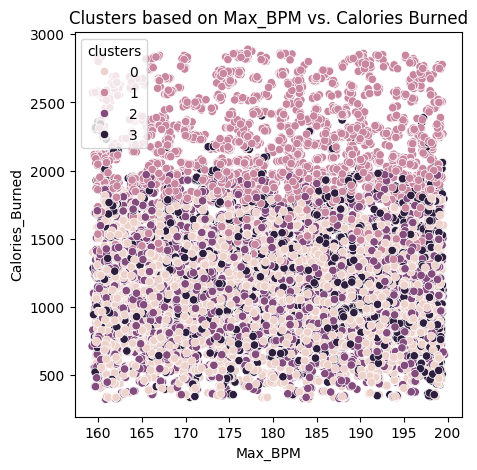

In [105]:
plt.figure(figsize=(5, 5))
sns.scatterplot(x = "Max_BPM", y = "Calories_Burned", data = data, hue = "clusters" )
plt.title("Clusters based on Max_BPM vs. Calories Burned")

In [106]:
workout_type_dist = data.groupby("clusters")["Workout_Type"].value_counts()
print(workout_type_dist)

clusters  Workout_Type
0         Yoga            2214
          Cardio          2037
          Strength        1948
          HIIT            1694
1         HIIT            1226
          Strength         872
          Cardio           706
          Yoga             344
2         Yoga            1546
          Strength        1446
          Cardio          1351
          HIIT            1296
3         Yoga             928
          Cardio           829
          Strength         805
          HIIT             758
Name: count, dtype: int64


In [107]:
workout_type_dist2 = data.groupby("clusters")["Workout_Type"].apply(lambda x: x.mode()[0])
workout_type_dist2

,Workout_Type
clusters,
0,Yoga
1,HIIT
2,Yoga
3,Yoga


In [108]:
data['cluster_workout_type'] = data['clusters'].map(workout_type_dist2)
data.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,...,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc,Burns_Calories_Bin,clusters,cluster_workout_type
0,34.91,Male,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,Strength,...,1.624789,0.741237,0.835985,725.10,47.777394,685.1600,7.260425e+19,Medium,0,Yoga
1,23.37,Female,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,HIIT,...,1.514093,0.551247,0.734270,-232.91,40.809803,978.6184,1.020506e+20,High,2,Yoga
2,33.20,Female,58.98,1.67,175.04,123.95,54.96,0.91,802.26,Cardio,...,1.663445,0.574534,0.708124,805.74,44.635580,654.5266,1.079607e+20,High,2,Yoga
3,38.69,Female,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,HIIT,...,0.862017,0.744155,0.811150,1206.21,63.007432,773.6300,8.987921e+19,High,3,Yoga
4,45.09,Male,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,Strength,...,2.538153,0.668405,0.789751,303.60,43.347504,711.4176,5.264685e+19,Low,0,Yoga


Text(0.5, 1.0, 'Clusters based on Max BPM vs. Calories Burned')

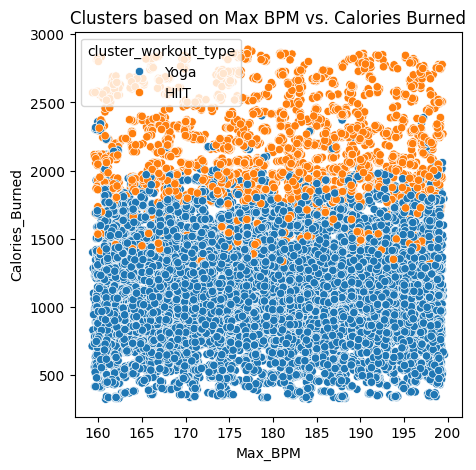

In [109]:
plt.figure(figsize=(5, 5))
sns.scatterplot(x='Max_BPM', y='Calories_Burned', hue='cluster_workout_type', data=data)
plt.title('Clusters based on Max BPM vs. Calories Burned')


Text(0.5, 1.0, 'Clusters based on Session Duration vs. Calories Burned')

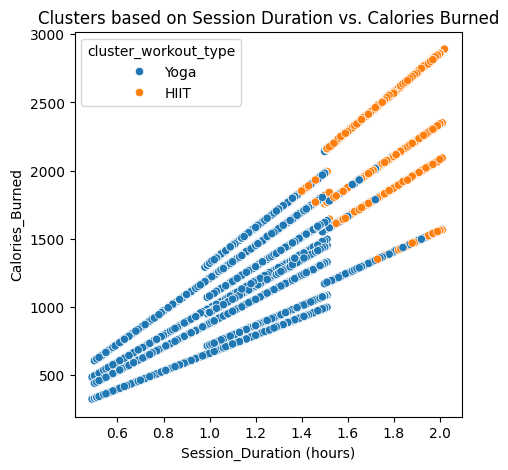

In [110]:
plt.figure(figsize=(5, 5))
sns.scatterplot(x='Session_Duration (hours)', y='Calories_Burned', hue='cluster_workout_type', data=data)
plt.title('Clusters based on Session Duration vs. Calories Burned')

In [111]:
encoder = OneHotEncoder(handle_unknown = "ignore", sparse_output = False)
workout_type_encoded = encoder.fit_transform(data[["Workout_Type"]])
print(workout_type_encoded)
print(encoder.get_feature_names_out(['Workout_Type']))
workout_type_df = pd.DataFrame(workout_type_encoded, columns = encoder.get_feature_names_out(['Workout_Type']))
data_encoded2 = pd.concat([data_encoded, workout_type_df], axis = 1)
data_encoded2.head()

[[0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 ...
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]]
['Workout_Type_Cardio' 'Workout_Type_HIIT' 'Workout_Type_Strength'
 'Workout_Type_Yoga']


,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Gender_Female,Gender_Male,Workout_Type_Cardio,Workout_Type_HIIT,Workout_Type_Strength,Workout_Type_Yoga
0,34.91,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,0.0,1.0,0.0,0.0,1.0,0.0
1,23.37,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,1.0,0.0,0.0,1.0,0.0,0.0
2,33.20,58.98,1.67,175.04,123.95,54.96,0.91,802.26,1.0,0.0,1.0,0.0,0.0,0.0
3,38.69,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,1.0,0.0,0.0,1.0,0.0,0.0
4,45.09,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,0.0,1.0,0.0,0.0,1.0,0.0


In [112]:
data_standardized2 = standardizer.fit_transform(data_encoded2)
data_standardized_df2 = pd.DataFrame(data_standardized2, columns = data_encoded2.columns)

data_standardized_df2

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Gender_Female,Gender_Male,Workout_Type_Cardio,Workout_Type_HIIT,Workout_Type_Strength,Workout_Type_Yoga
0,-0.325356,-0.407549,-0.811571,0.754988,0.977456,0.940325,-0.760110,-0.396661,-1.002804,1.002804,-0.571423,-0.575349,1.715807,-0.579814
1,-1.277951,-0.826017,-1.362623,-0.039938,-0.837880,1.506919,0.323893,1.054924,0.997204,-0.997204,-0.571423,1.738076,-0.582816,-0.579814
2,-0.466512,-0.704633,-0.417962,-0.421328,-1.384583,-0.992680,-1.023786,-0.951481,0.997204,-0.997204,1.750018,-0.575349,-0.582816,-0.579814
3,-0.013328,0.939010,-0.181796,0.983474,0.798726,-1.663539,-0.467136,0.339854,0.997204,-0.997204,-0.571423,1.738076,-0.582816,-0.579814
4,0.514975,-1.014469,1.235196,1.189373,0.643126,1.185895,-0.525731,-0.226416,-1.002804,1.002804,-0.571423,-0.575349,1.715807,-0.579814
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,0.653654,1.152967,1.392640,1.677622,0.313702,0.209103,-1.433949,-1.032423,0.997204,-0.997204,-0.571423,-0.575349,1.715807,-0.579814
19996,0.126177,0.671682,1.156474,1.415253,-0.667560,-1.118895,2.081734,2.037011,0.997204,-0.997204,-0.571423,-0.575349,1.715807,-0.579814
19997,0.945871,-1.308247,-0.417962,-1.437790,0.996381,-0.074880,0.294595,0.375715,-1.002804,1.002804,-0.571423,-0.575349,1.715807,-0.579814
19998,1.115093,-1.397986,-0.811571,-0.053838,-1.575228,-0.180516,0.441082,-0.697627,-1.002804,1.002804,-0.571423,-0.575349,-0.582816,1.724692


In [113]:
inertias = []
for k in range(1,11):
  km = KMeans(n_clusters = k)
  km.fit(data_standardized_df2)
  clusters = km.predict(data_standardized_df2)
  inertias.append(km.inertia_)
inertias

[279999.9999999995,
 249254.63694281236,
 221692.40270864373,
 205620.58782006416,
 187575.33370133492,
 174057.73002887005,
 164212.24120729108,
 154066.2022245837,
 159002.83166009482,
 149102.95150113586]

Text(0, 0.5, 'Inertias')

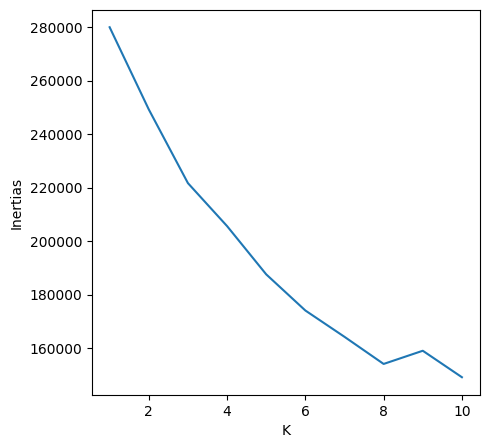

In [114]:
plt.figure(figsize=(5, 5))
plt.plot(range(1,11), inertias)
plt.xlabel("K")
plt.ylabel("Inertias")


Text(0, 0.5, 'Silhouette Score')

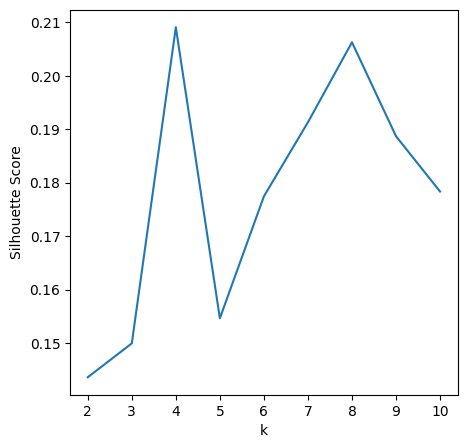

In [115]:
silhouette_list = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(data_standardized_df2)
    clusters = kmeans.predict(data_standardized_df2)
    score = silhouette_score(data_standardized_df2,clusters)
    silhouette_list.append(score)

plt.figure(figsize=(5, 5))
plt.plot(range(2,11), silhouette_list)
plt.xlabel("k")
plt.ylabel("Silhouette Score")

In [116]:
km4 = KMeans(n_clusters = 4, random_state = 42, n_init = "auto")
km4.fit(data_standardized_df2)
clusters = km4.predict(data_standardized_df2)
clusters


array([1, 3, 0, ..., 1, 2, 2], dtype=int32)

In [117]:
km4.inertia_

194075.860346646

In [118]:
data['clusters'] = clusters
data

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,...,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc,Burns_Calories_Bin,clusters,cluster_workout_type
0,34.91,Male,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,Strength,...,1.624789,0.741237,0.835985,725.10,47.777394,685.1600,7.260425e+19,Medium,1,Yoga
1,23.37,Female,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,HIIT,...,1.514093,0.551247,0.734270,-232.91,40.809803,978.6184,1.020506e+20,High,3,Yoga
2,33.20,Female,58.98,1.67,175.04,123.95,54.96,0.91,802.26,Cardio,...,1.663445,0.574534,0.708124,805.74,44.635580,654.5266,1.079607e+20,High,0,Yoga
3,38.69,Female,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,HIIT,...,0.862017,0.744155,0.811150,1206.21,63.007432,773.6300,8.987921e+19,High,3,Yoga
4,45.09,Male,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,Strength,...,2.538153,0.668405,0.789751,303.60,43.347504,711.4176,5.264685e+19,Low,1,Yoga
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,46.77,Female,98.31,1.90,199.20,148.18,63.72,0.77,761.61,Strength,...,0.954837,0.623413,0.743876,1865.39,71.269345,533.2558,7.924402e+19,Medium,1,Yoga
19996,40.38,Female,88.12,1.87,196.18,134.18,54.04,1.97,2303.13,Strength,...,0.689060,0.563810,0.683964,173.87,65.049689,1310.6016,5.708474e+19,Low,1,HIIT
19997,50.31,Male,46.20,1.67,163.34,157.92,61.65,1.36,1468.80,Strength,...,2.105844,0.946701,0.966818,-43.80,35.420708,957.9568,9.101285e+19,High,1,Yoga
19998,52.36,Male,44.30,1.62,179.27,121.23,60.88,1.41,929.75,Yoga,...,2.190745,0.509756,0.676243,346.25,35.889260,928.4004,5.246436e+19,Low,2,Yoga


In [119]:
workout_type_dist = data.groupby("clusters")["Workout_Type"].value_counts()
print(workout_type_dist)
workout_type_dist2 = data.groupby("clusters")["Workout_Type"].apply(lambda x: x.mode()[0])
workout_type_dist2
data['cluster_workout_type'] = data['clusters'].map(workout_type_dist2)
data.head()

clusters  Workout_Type
0         Cardio          4923
1         Strength        5071
2         Yoga            5032
3         HIIT            4974
Name: count, dtype: int64


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,...,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc,Burns_Calories_Bin,clusters,cluster_workout_type
0,34.91,Male,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,Strength,...,1.624789,0.741237,0.835985,725.10,47.777394,685.1600,7.260425e+19,Medium,1,Strength
1,23.37,Female,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,HIIT,...,1.514093,0.551247,0.734270,-232.91,40.809803,978.6184,1.020506e+20,High,3,HIIT
2,33.20,Female,58.98,1.67,175.04,123.95,54.96,0.91,802.26,Cardio,...,1.663445,0.574534,0.708124,805.74,44.635580,654.5266,1.079607e+20,High,0,Cardio
3,38.69,Female,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,HIIT,...,0.862017,0.744155,0.811150,1206.21,63.007432,773.6300,8.987921e+19,High,3,HIIT
4,45.09,Male,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,Strength,...,2.538153,0.668405,0.789751,303.60,43.347504,711.4176,5.264685e+19,Low,1,Strength


Text(0.5, 1.0, 'Clusters based on Max_BPM vs. Calories Burned')

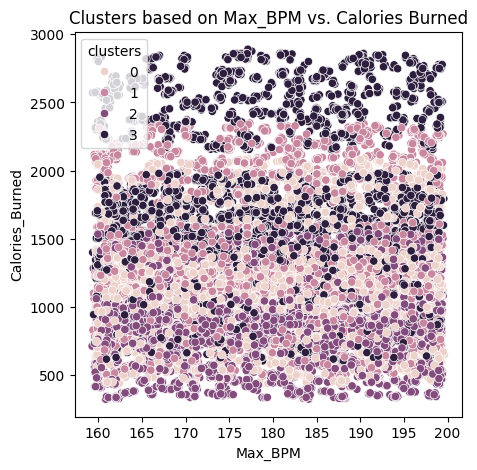

In [120]:
plt.figure(figsize=(5, 5))
sns.scatterplot(x = "Max_BPM", y = "Calories_Burned", data = data, hue = "clusters" )
plt.title("Clusters based on Max_BPM vs. Calories Burned")

Text(0.5, 1.0, 'Clusters based on Session Duration vs. Calories Burned')

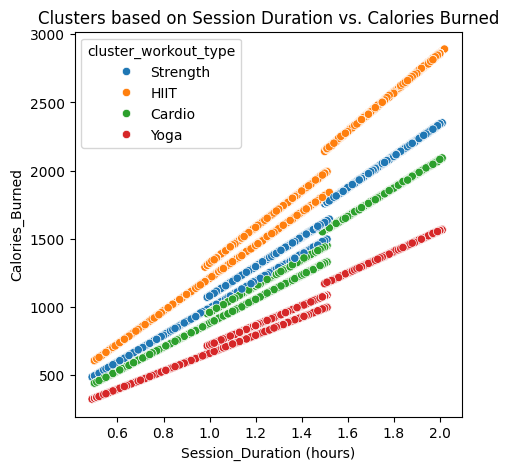

In [121]:
plt.figure(figsize=(5, 5))
sns.scatterplot(x='Session_Duration (hours)', y='Calories_Burned', hue='cluster_workout_type', data=data)
plt.title('Clusters based on Session Duration vs. Calories Burned')

In [122]:
print(data['cluster_workout_type'].nunique())
print(data['cluster_workout_type'].value_counts())

4
cluster_workout_type
Strength    5071
Yoga        5032
HIIT        4974
Cardio      4923
Name: count, dtype: int64


Text(0.5, 1.0, 'Workout Type vs. Calories_Burned')

<Figure size 500x500 with 0 Axes>

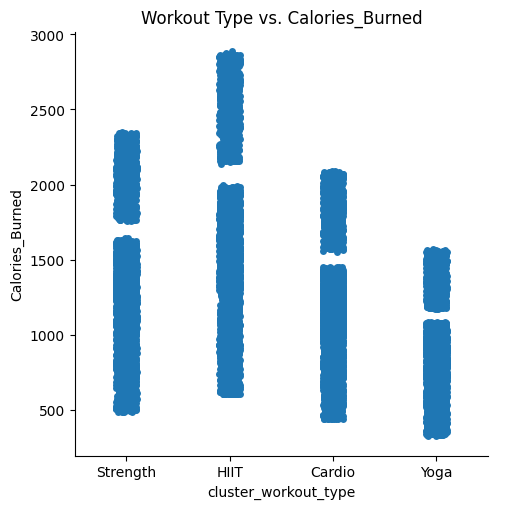

In [123]:
plt.figure(figsize=(5, 5))
sns.catplot(x = "cluster_workout_type", y ="Calories_Burned", data = data)
plt.title("Workout Type vs. Calories_Burned")

Text(0.5, 1.0, 'Workout Type vs. Calories_Burned')

<Figure size 500x500 with 0 Axes>

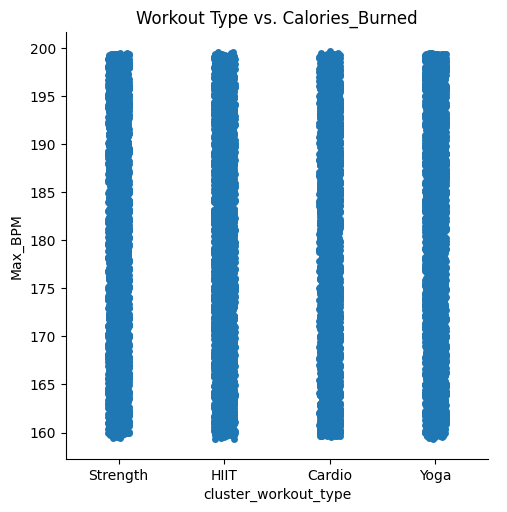

In [124]:
plt.figure(figsize=(5, 5))
sns.catplot(x = "cluster_workout_type", y ="Max_BPM", data = data)
plt.title("Workout Type vs. Calories_Burned")